In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
df_data = pd.read_csv("/home/parrot/Documents/machine_learning/datasets/kidney_disease.csv")


In [3]:
df_data = df_data.drop(columns=['id'])


In [4]:
df_data.columns = [
    'age','blood_pressure','specific_gravity','albumin','sugar',
    'red_blood_cells','pus_cell','pus_cell_clumps','bacteria',
    'blood_glucose_random','blood_urea','serum_creatinine','sodium',
    'potassium','haemoglobin','packed_cell_volume',
    'white_blood_cell_count','red_blood_cell_count','hypertension',
    'diabetes_mellitus','coronary_artery_disease','appetite',
    'peda_edema','anemia','class'
]


In [5]:
df_data['class'].value_counts

<bound method IndexOpsMixin.value_counts of 0         ckd
1         ckd
2         ckd
3         ckd
4         ckd
        ...  
395    notckd
396    notckd
397    notckd
398    notckd
399    notckd
Name: class, Length: 400, dtype: object>

In [6]:
# Convert known numeric columns
num_fix_cols = [
    'packed_cell_volume',
    'white_blood_cell_count',
    'red_blood_cell_count'
]

for col in num_fix_cols:
    df_data[col] = pd.to_numeric(df_data[col], errors='coerce')


In [7]:
# Clean string columns FIRST
for col in df_data.select_dtypes(include='object').columns:
    df_data[col] = (
        df_data[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace('\t', '', regex=False)
    )


In [8]:
# Fix inconsistent labels
df_data['diabetes_mellitus'] = df_data['diabetes_mellitus'].replace({' yes':'yes'})
df_data['coronary_artery_disease'] = df_data['coronary_artery_disease'].replace({'\tno':'no'})
df_data['class'] = df_data['class'].replace({'ckd\t':'ckd', 'notckd':'notckd', 'not ckd':'notckd'})


In [9]:
# Imputation functions
def mean_value_imputation(df_data, column):
    df_data[column] = df_data[column].fillna(df_data[column].mean())

def mode_value_imputation(df_data, column):
    df_data[column] = df_data[column].fillna(df_data[column].mode()[0])


In [10]:
# Apply imputation
num_col = [col for col in df_data.columns if df_data[col].dtype != 'object']
cat_col = [col for col in df_data.columns if df_data[col].dtype == 'object']

for col in num_col:
    mean_value_imputation(df_data, col)

for col in cat_col:
    mode_value_imputation(df_data, col)


In [11]:
# Encode categorical variables
df_data['class'] = df_data['class'].map({'ckd': 1, 'notckd': 0})

df_data['red_blood_cells'] = df_data['red_blood_cells'].map({'normal': 1, 'abnormal': 0})
df_data['pus_cell'] = df_data['pus_cell'].map({'normal': 1, 'abnormal': 0})
df_data['pus_cell_clumps'] = df_data['pus_cell_clumps'].map({'present': 1, 'notpresent': 0})
df_data['bacteria'] = df_data['bacteria'].map({'present': 1, 'notpresent': 0})
df_data['hypertension'] = df_data['hypertension'].map({'yes': 1, 'no': 0})
df_data['diabetes_mellitus'] = df_data['diabetes_mellitus'].map({'yes': 1, 'no': 0})
df_data['coronary_artery_disease'] = df_data['coronary_artery_disease'].map({'yes': 1, 'no': 0})
df_data['appetite'] = df_data['appetite'].map({'good': 1, 'poor': 0})
df_data['peda_edema'] = df_data['peda_edema'].map({'yes': 1, 'no': 0})
df_data['anemia'] = df_data['anemia'].map({'yes': 1, 'no': 0})


In [12]:
# Final NaN check
print(df_data.isnull().sum())


age                          0
blood_pressure               0
specific_gravity             0
albumin                      0
sugar                        0
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random         0
blood_urea                   0
serum_creatinine             0
sodium                       0
potassium                    0
haemoglobin                  0
packed_cell_volume           0
white_blood_cell_count       0
red_blood_cell_count         0
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
anemia                       1
class                        0
dtype: int64


In [13]:
df_data.head()


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,1.0,0.0,0.0,121.000000,...,44.0,7800.0,5.200000,1.0,1.0,0.0,1.0,0.0,0.0,1
1,7.0,50.0,1.020,4.0,0.0,NaN,1.0,0.0,0.0,148.036517,...,38.0,6000.0,4.707435,0.0,0.0,0.0,1.0,0.0,0.0,1
2,62.0,80.0,1.010,2.0,3.0,1.0,1.0,0.0,0.0,423.000000,...,31.0,7500.0,4.707435,0.0,1.0,0.0,0.0,0.0,1.0,1
3,48.0,70.0,1.005,4.0,0.0,1.0,0.0,1.0,0.0,117.000000,...,32.0,6700.0,3.900000,1.0,0.0,0.0,0.0,1.0,1.0,1
4,51.0,80.0,1.010,2.0,0.0,1.0,1.0,0.0,0.0,106.000000,...,35.0,7300.0,4.600000,0.0,0.0,0.0,1.0,0.0,0.0,1


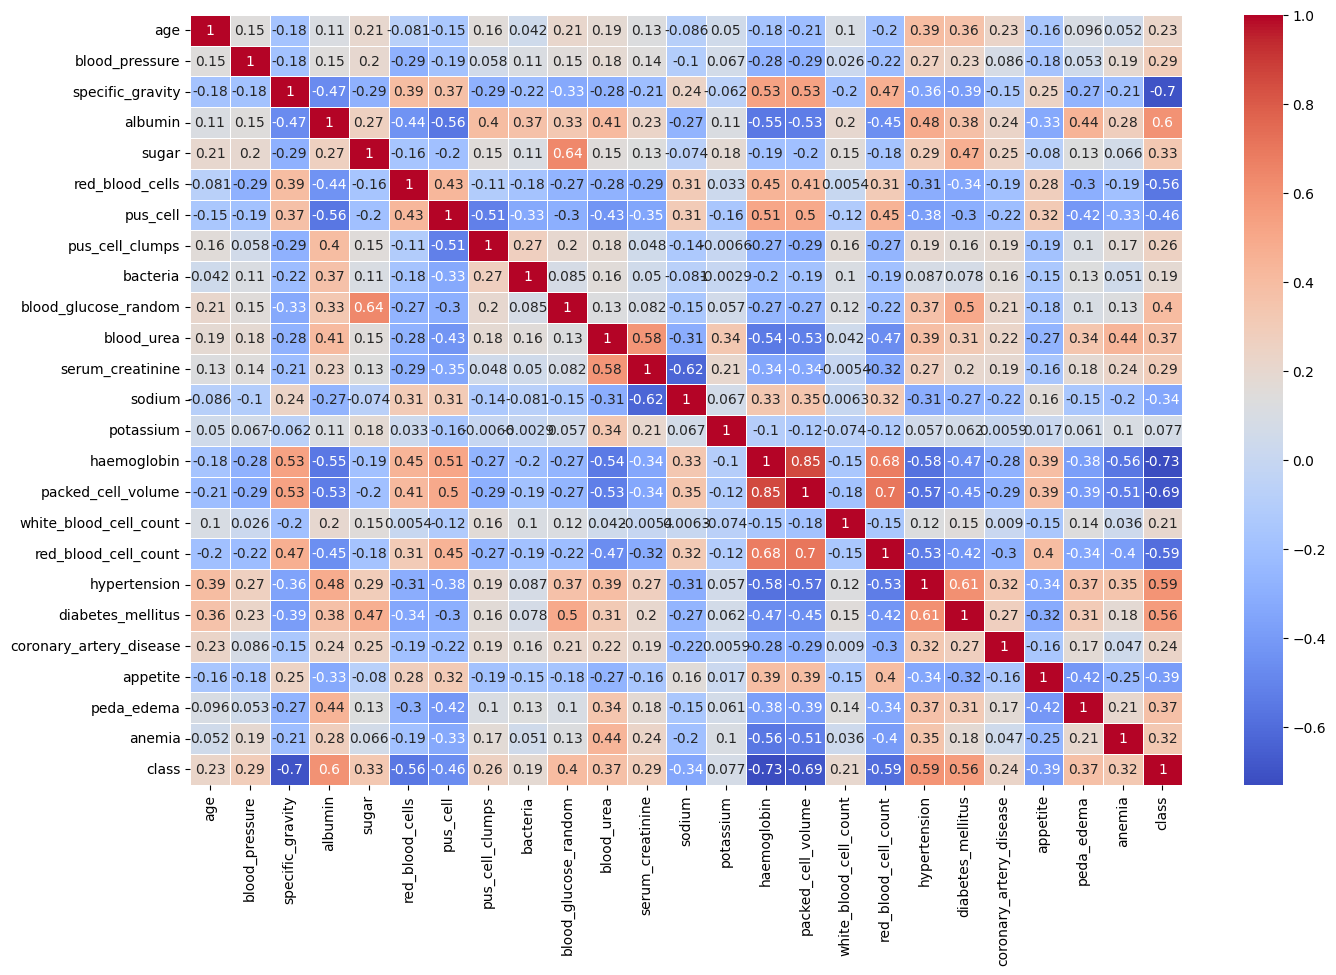

In [14]:
# Correlation heatmap (numeric only)
plt.figure(figsize=(16, 10))
sns.heatmap(df_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()


In [15]:
# Target correlation
target_corr = df_data.corr()['class'].abs().sort_values(ascending=False)[1:]
print(target_corr)


haemoglobin                0.729628
specific_gravity           0.698957
packed_cell_volume         0.690060
albumin                    0.599238
red_blood_cell_count       0.590913
hypertension               0.588820
diabetes_mellitus          0.557444
red_blood_cells            0.555097
pus_cell                   0.461812
blood_glucose_random       0.401374
appetite                   0.392645
peda_edema                 0.374480
blood_urea                 0.372033
sodium                     0.342288
sugar                      0.327812
anemia                     0.324787
serum_creatinine           0.294079
blood_pressure             0.290600
pus_cell_clumps            0.263226
coronary_artery_disease    0.235153
age                        0.225405
white_blood_cell_count     0.205274
bacteria                   0.185345
potassium                  0.076921
Name: class, dtype: float64


In [16]:
print(df_data['class'].unique())


[1 0]


In [17]:
df_data['class'].value_counts()

class
1    250
0    150
Name: count, dtype: int64

In [18]:
X=df_data.drop('class',axis=1)
y=df_data['class']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=25)
print(X_train.shape)
print(X_test.shape)

(300, 24)
(100, 24)


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import  GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [20]:

models = [
    DecisionTreeClassifier(random_state=42),
    GaussianNB(),
    KNeighborsClassifier(n_neighbors=8),
    SVC(kernel='linear', probability=True),
    RandomForestClassifier(random_state=42)
]

In [21]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,recall_score,precision_score

In [24]:
for model in models:
    print("=" * 50)
    print(model.__class__.__name__)

    # Fill NaN only for models that cannot handle them
    if model.__class__.__name__ in ["GaussianNB", "KNeighborsClassifier", "SVC"]:
        model.fit(X_train.fillna(0), y_train)
        y_pred = model.predict(X_test.fillna(0))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))

DecisionTreeClassifier
Confusion Matrix:
[[35  2]
 [ 1 62]]
Accuracy: 0.97
F1 Score: 0.9763779527559056
Precision: 0.96875
Recall: 0.9841269841269841
GaussianNB
Confusion Matrix:
[[35  2]
 [ 4 59]]
Accuracy: 0.94
F1 Score: 0.9516129032258065
Precision: 0.9672131147540983
Recall: 0.9365079365079365
KNeighborsClassifier


Confusion Matrix:
[[31  6]
 [18 45]]
Accuracy: 0.76
F1 Score: 0.7894736842105263
Precision: 0.8823529411764706
Recall: 0.7142857142857143
SVC
Confusion Matrix:
[[34  3]
 [ 4 59]]
Accuracy: 0.93
F1 Score: 0.944
Precision: 0.9516129032258065
Recall: 0.9365079365079365
RandomForestClassifier
Confusion Matrix:
[[36  1]
 [ 0 63]]
Accuracy: 0.99
F1 Score: 0.9921259842519685
Precision: 0.984375
Recall: 1.0
